# <p style="text-align: center; font-size: 2.5rem">Notebook II</p>

<p style="text-align: center; font-size: 2rem">Part a</p>

This notebook contains the cleaning and wrangling of the Marine Mammal Strandings Dataset for animals stranded along the south-east coast of the United States.

Data should be ingested from the `data/raw/UNC-DataRequest-01302026.xlsx` file and any files containing cleaned data should go in the `data/processed/` directory.


In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

In [3]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "strandings.parquet")
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:5070",
)

In [4]:
plot_gdf = gdf[~gdf["Common Name"].str.contains("bottlenose", case=False, na=False)]

plot_gdf["Common Name"].value_counts()

Common Name
Dolphin, common, short-beaked                    73
Whale, humpback                                  72
Whale, pygmy sperm                               65
Porpoise, harbor                                 55
Seal, harbor                                     54
Dolphin, unidentified                            48
Whale, dwarf sperm                               39
Dolphin, Atlantic spotted                        30
Seal, gray                                       30
Whale, minke                                     24
Whale, Gervais' beaked                           22
Seal, harp                                       17
Whale, pilot, short-finned                       16
Cetacean, unidentified                           11
Whale, unidentified Kogia (dwarf/pygmy sperm)     9
Dolphin, striped                                  8
Dolphin, Risso's                                  8
Whale, sperm                                      7
Whale, right, North Atlantic                      6


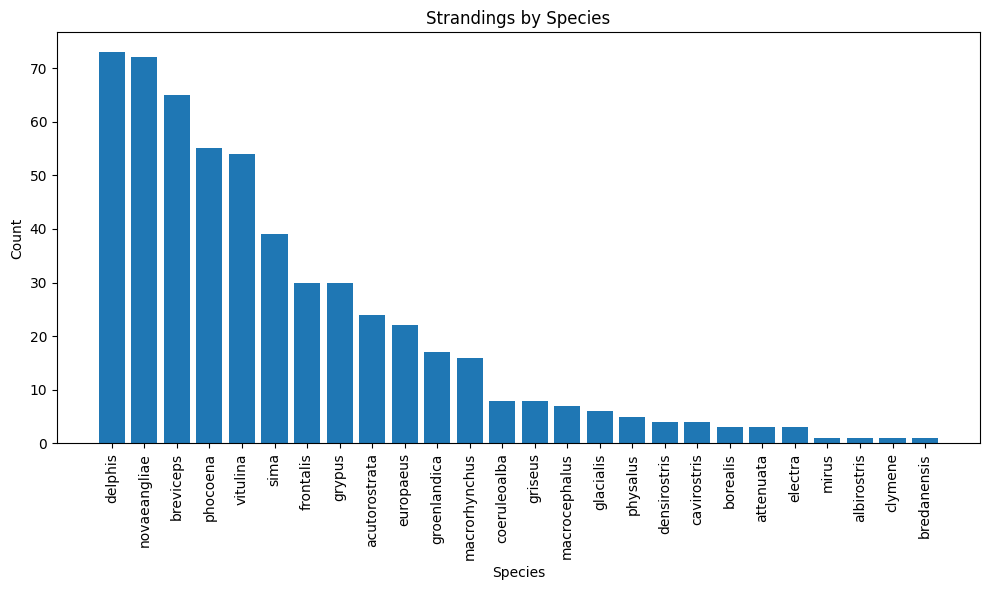

In [5]:
plt.figure(figsize=(10, 6))
plt.bar(
    plot_gdf["Species"].value_counts().index,
    plot_gdf["Species"].value_counts().values,
)
plt.xticks(rotation=90)
plt.title("Strandings by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()